In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [2]:
FILE_PATH = Path("DaneRDN_2025.xlsx")
SHEET_NAME = "Dane"

RENAME_MAP = {
    "Data": "timestamp",
    "Godzina handlowa nr": "hour_no",
    "Godzina handlowa przedział": "hour_interval",
    "Data dostawy/delivery date": "delivery_date",
    "Cena RDN\n[zł/MWh]": "price_rdn",
    "Cena CEN\n(rynek bilansujący)\n[zł/MWh]": "price_bal",
    "Saldo wymiany międzysystemowej\n[MW]": "interchange_balance_mw",
    "Średnia z Rzeczywiste zapotrzebowanie KSE": "load_kse",
    "Średnia z Różnica rzeczywiste a planowane zapotrzebowanie KSE [MW]": "load_diff_real_vs_planned",
    "Udział generacji wiatrowej": "wind_share",
    "Udział generacji PV": "pv_share",
    "Udział generacji PV i wiatrowej": "res_share",
    "Średnia temperatura w Polsce °C": "temp_avg_pl"
}

NUMERIC_COLS = [
    "price_rdn", "price_bal", "interchange_balance_mw", "load_kse",
    "load_diff_real_vs_planned", "wind_share", "pv_share", "res_share", "temp_avg_pl"
]

In [3]:
def load_and_prepare_data(file_path: Path, sheet_name: str) -> pd.DataFrame:

    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df.rename(columns=RENAME_MAP).dropna(how="all").copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["delivery_date"] = pd.to_datetime(df["delivery_date"])

    #Sortowanie po czasie oraz numerze godziny handlowej
    df = df.sort_values(["timestamp", "hour_no"]).reset_index(drop=True)

    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    df["weekday"] = df["timestamp"].dt.dayofweek
    df["month"] = df["timestamp"].dt.month
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

    return df

In [4]:
df = load_and_prepare_data(FILE_PATH, SHEET_NAME)

print("Liczba obserwacji:", len(df))
print("Zakres dat:", df["timestamp"].min(), "->", df["timestamp"].max())
print("\nTypy danych:")
print(df.dtypes)

df.head()

Liczba obserwacji: 8760
Zakres dat: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00

Typy danych:
timestamp                    datetime64[ns]
hour_no                               int64
hour_interval                        object
delivery_date                datetime64[ns]
price_rdn                           float64
price_bal                           float64
interchange_balance_mw              float64
load_kse                            float64
load_diff_real_vs_planned           float64
wind_share                          float64
pv_share                            float64
res_share                           float64
temp_avg_pl                         float64
date                                 object
hour                                  int32
weekday                               int32
month                                 int32
is_weekend                            int64
dtype: object


,timestamp,hour_no,hour_interval,delivery_date,price_rdn,price_bal,interchange_balance_mw,load_kse,load_diff_real_vs_planned,wind_share,pv_share,res_share,temp_avg_pl,date,hour,weekday,month,is_weekend
0,2025-01-01 00:00:00,1,00:00-01:00,2025-01-01 00:00:00,65.96,208.9575,-2002.54000,14160.87300,485.87300,0.455148,0.0,0.455148,2.2,2025-01-01,0,2,1,0
1,2025-01-01 01:00:00,2,01:00-02:00,2025-01-01 01:00:00,9.37,190.8825,-2155.86150,14291.79650,1191.79650,0.457082,0.0,0.457082,2.2,2025-01-01,1,2,1,0
2,2025-01-01 02:00:00,3,02:00-03:00,2025-01-01 02:00:00,9.31,277.8125,-2658.46925,13816.05300,1228.55300,0.464321,0.0,0.464321,2.2,2025-01-01,2,2,1,0
3,2025-01-01 03:00:00,4,03:00-04:00,2025-01-01 03:00:00,7.23,347.7150,-2916.94025,13381.09675,1231.09675,0.457696,0.0,0.457696,2.2,2025-01-01,3,2,1,0
4,2025-01-01 04:00:00,5,03:00-05:00,2025-01-01 04:00:00,0.40,204.1350,-2792.94600,13199.56775,1149.56775,0.412265,0.0,0.412265,2.2,2025-01-01,4,2,1,0


In [5]:
desc = df[NUMERIC_COLS].describe().T
print("Statystyki opisowe:")
print(desc)

negative_prices = (df["price_rdn"] < 0).sum()
very_high_prices = (df["price_rdn"] > 1000).sum()

print(f"\nGodziny z ceną ujemną: {negative_prices}")
print(f"Godziny z ceną > 1000 zł/MWh: {very_high_prices}")
print(f"Udział cen ujemnych: {negative_prices / len(df):.2%}")
print(f"Udział cen > 1000 zł/MWh: {very_high_prices / len(df):.2%}")

Statystyki opisowe:
                            count          mean          std           min  \
price_rdn                  8760.0    442.237379   216.448024   -569.070000   
price_bal                  8760.0    437.553178   436.313944 -11327.115000   
interchange_balance_mw     8760.0     98.753244  1449.462350  -4741.731750   
load_kse                   8760.0  18065.273677  3050.534730  10595.800250   
load_diff_real_vs_planned  8760.0   -124.149468   549.944840  -5213.870750   
wind_share                 8760.0      0.141913     0.104117      0.003000   
pv_share                   8760.0      0.120497     0.174412      0.000000   
res_share                  8760.0      0.262410     0.177420      0.004801   
temp_avg_pl                8760.0      8.838607     7.459173     -8.400000   

                                    25%           50%           75%  \
price_rdn                    374.785000    443.525000    523.620000   
price_bal                    339.123125    458.008750    

In [6]:
monthly_stats = df.groupby("month")[["price_rdn", "load_kse", "res_share", "temp_avg_pl"]].mean().round(2)
weekday_stats = df.groupby("weekday")[["price_rdn", "load_kse", "res_share"]].mean().round(2)
hourly_stats = df.groupby("hour")[["price_rdn", "load_kse", "res_share", "pv_share", "wind_share"]].mean().round(2)

print("Średnie miesięczne:")
print(monthly_stats)

print("\nŚrednie wg dnia tygodnia (0=pon, 6=niedz):")
print(weekday_stats)

print("\nŚrednie wg godziny:")
print(hourly_stats)

Średnie miesięczne:
       price_rdn  load_kse  res_share  temp_avg_pl
month                                             
1         484.51  19783.52       0.25         1.36
2         558.77  20295.11       0.16        -1.64
3         415.41  18303.78       0.26         5.01
4         367.09  17154.84       0.30         9.74
5         401.10  16906.96       0.32        10.54
6         348.14  16558.15       0.39        17.55
7         436.30  17028.67       0.29        18.51
8         382.46  16272.41       0.30        17.46
9         458.77  17283.78       0.28        14.65
10        445.67  18469.36       0.26         7.41
11        524.98  19392.04       0.16         3.31
12        492.63  19489.83       0.17         1.49

Średnie wg dnia tygodnia (0=pon, 6=niedz):
         price_rdn  load_kse  res_share
weekday                                
0           475.40  18446.31       0.25
1           480.71  19081.43       0.25
2           460.71  18949.14       0.26
3           457.31  18

In [7]:
ACADEMIC_COLORS = {
    "primary": "#2563EB",
    "secondary": "#EA580C",
    "tertiary": "#16A34A",
    "quaternary": "#9333EA",
    "muted": "#64748B",
    "negative": "#DC2626",
    "grid": "#CBD5E1",
    "axis": "#334155",
    "text": "#111827",
    "background": "#FFFFFF",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": ACADEMIC_COLORS["background"],
    "axes.facecolor": ACADEMIC_COLORS["background"],
    "axes.edgecolor": ACADEMIC_COLORS["axis"],
    "axes.labelcolor": ACADEMIC_COLORS["text"],
    "axes.titlecolor": ACADEMIC_COLORS["text"],
    "axes.titleweight": "bold",
    "xtick.color": ACADEMIC_COLORS["text"],
    "ytick.color": ACADEMIC_COLORS["text"],
    "text.color": ACADEMIC_COLORS["text"],
    "grid.color": ACADEMIC_COLORS["grid"],
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.55,
    "legend.frameon": True,
    "legend.facecolor": ACADEMIC_COLORS["background"],
    "legend.edgecolor": ACADEMIC_COLORS["grid"],
    "legend.framealpha": 0.95,
    "axes.prop_cycle": plt.cycler(color=[
        ACADEMIC_COLORS["primary"],
        ACADEMIC_COLORS["secondary"],
        ACADEMIC_COLORS["tertiary"],
        ACADEMIC_COLORS["quaternary"],
        ACADEMIC_COLORS["muted"],
        ACADEMIC_COLORS["negative"],
    ]),
})


def style_axes(ax, grid: bool = True):
    ax.set_facecolor(ACADEMIC_COLORS["background"])
    ax.set_axisbelow(True)
    if grid:
        ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.55, color=ACADEMIC_COLORS["grid"])
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACADEMIC_COLORS["axis"])
        spine.set_linewidth(0.8)
    ax.tick_params(colors=ACADEMIC_COLORS["text"], labelsize=9)
    ax.xaxis.label.set_color(ACADEMIC_COLORS["text"])
    ax.yaxis.label.set_color(ACADEMIC_COLORS["text"])
    ax.title.set_color(ACADEMIC_COLORS["text"])
    return ax


def style_figure(fig):
    fig.patch.set_facecolor(ACADEMIC_COLORS["background"])
    return fig


month_labels = {
    1: "I", 2: "II", 3: "III", 4: "IV", 5: "V", 6: "VI",
    7: "VII", 8: "VIII", 9: "IX", 10: "X", 11: "XI", 12: "XII"
}

weekday_labels = {
    0: "Poniedziałek", 1: "Wtorek", 2: "Środa", 3: "Czwartek",
    4: "Piątek", 5: "Sobota", 6: "Niedziela"
}

monthly = df.groupby("month")[["price_rdn", "load_kse", "res_share", "pv_share", "wind_share"]].mean()
hourly = df.groupby("hour")[["price_rdn", "load_kse", "res_share", "pv_share", "wind_share"]].mean()
weekday = df.groupby("weekday")[["price_rdn", "load_kse", "res_share"]].mean()


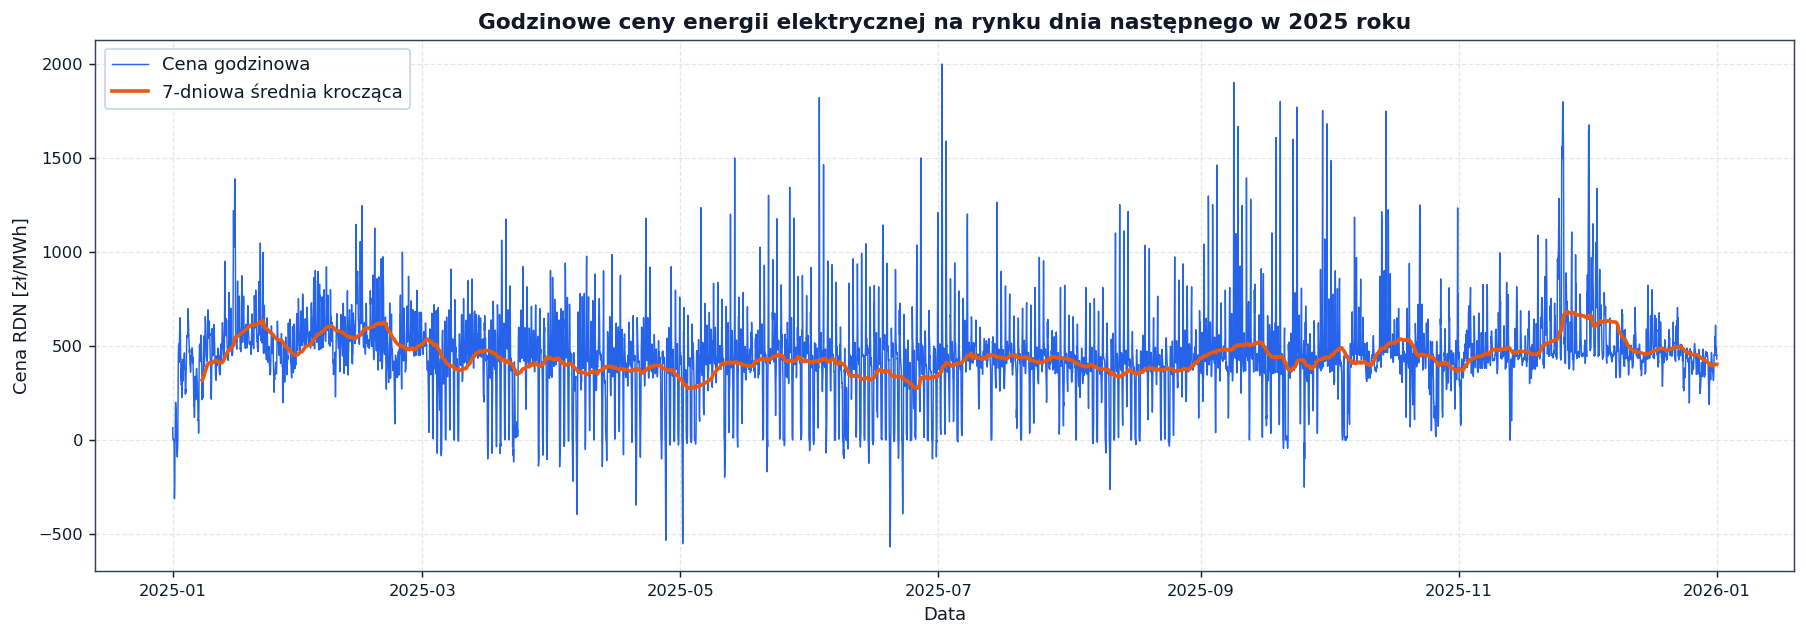

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
style_figure(fig)
style_axes(ax)

ax.plot(
    df["timestamp"], df["price_rdn"],
    linewidth=0.8,
    color=ACADEMIC_COLORS["primary"],
    label="Cena godzinowa"
)
ax.plot(
    df["timestamp"], df["price_rdn"].rolling(24 * 7).mean(),
    linewidth=2,
    color=ACADEMIC_COLORS["secondary"],
    label="7-dniowa średnia krocząca"
)
ax.set_title("Godzinowe ceny energii elektrycznej na rynku dnia następnego w 2025 roku")
ax.set_xlabel("Data")
ax.set_ylabel("Cena RDN [zł/MWh]")
ax.legend()
plt.tight_layout()
plt.show()


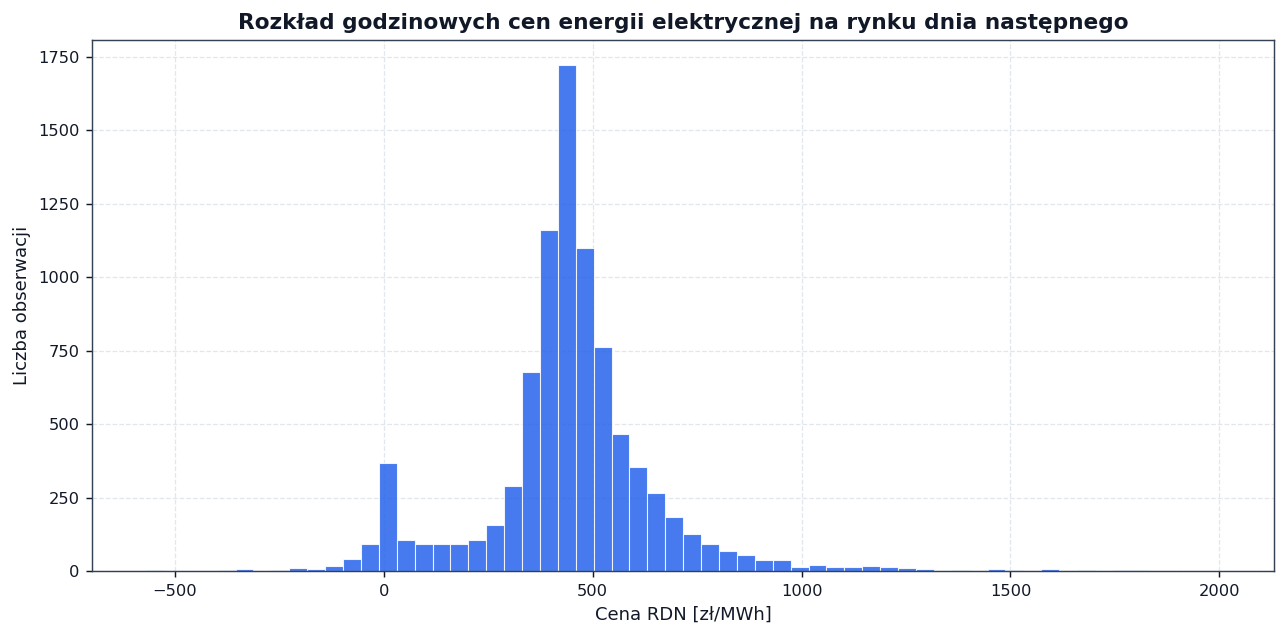

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
style_figure(fig)
style_axes(ax)

ax.hist(
    df["price_rdn"].dropna(),
    bins=60,
    color=ACADEMIC_COLORS["primary"],
    edgecolor=ACADEMIC_COLORS["background"],
    linewidth=0.6,
    alpha=0.85
)
ax.set_title("Rozkład godzinowych cen energii elektrycznej na rynku dnia następnego")
ax.set_xlabel("Cena RDN [zł/MWh]")
ax.set_ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()


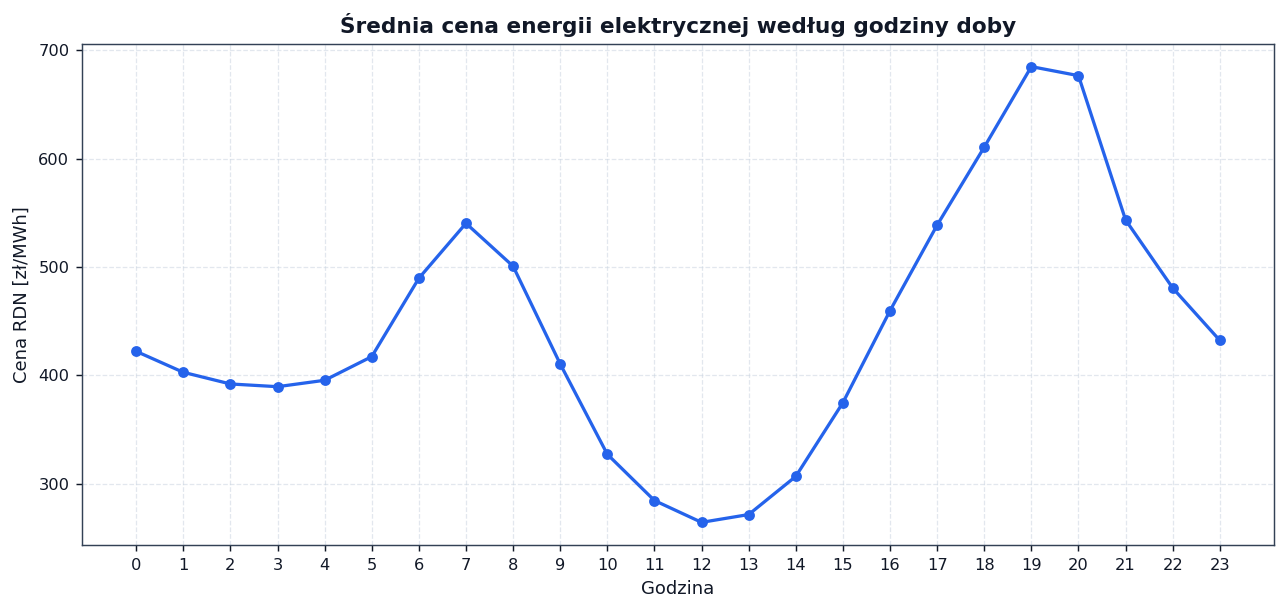

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
style_figure(fig)
style_axes(ax)

ax.plot(
    hourly.index, hourly["price_rdn"],
    marker="o",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["primary"]
)
ax.set_title("Średnia cena energii elektrycznej według godziny doby")
ax.set_xlabel("Godzina")
ax.set_ylabel("Cena RDN [zł/MWh]")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()


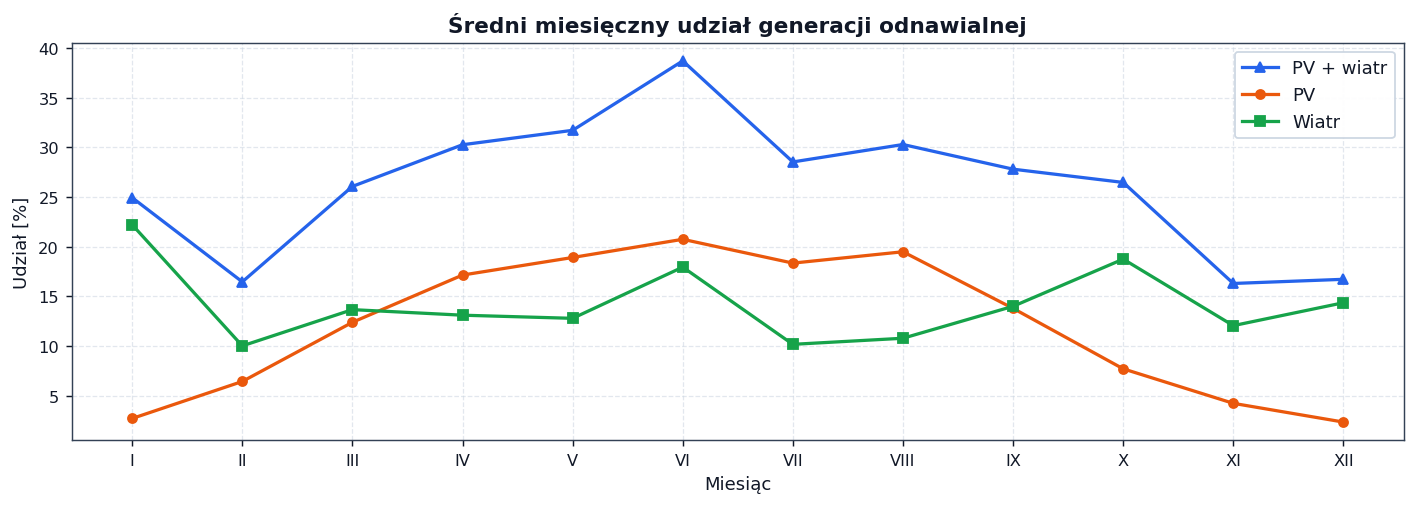

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
style_figure(fig)
style_axes(ax)

ax.plot(
    monthly.index, monthly["res_share"] * 100,
    marker="^",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["primary"],
    label="PV + wiatr"
)
ax.plot(
    monthly.index, monthly["pv_share"] * 100,
    marker="o",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["secondary"],
    label="PV"
)
ax.plot(
    monthly.index, monthly["wind_share"] * 100,
    marker="s",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["tertiary"],
    label="Wiatr"
)

ax.set_title("Średni miesięczny udział generacji odnawialnej")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Udział [%]")
ax.set_xticks(list(monthly.index))
ax.set_xticklabels([month_labels[m] for m in monthly.index])
ax.legend()

plt.tight_layout()
plt.show()


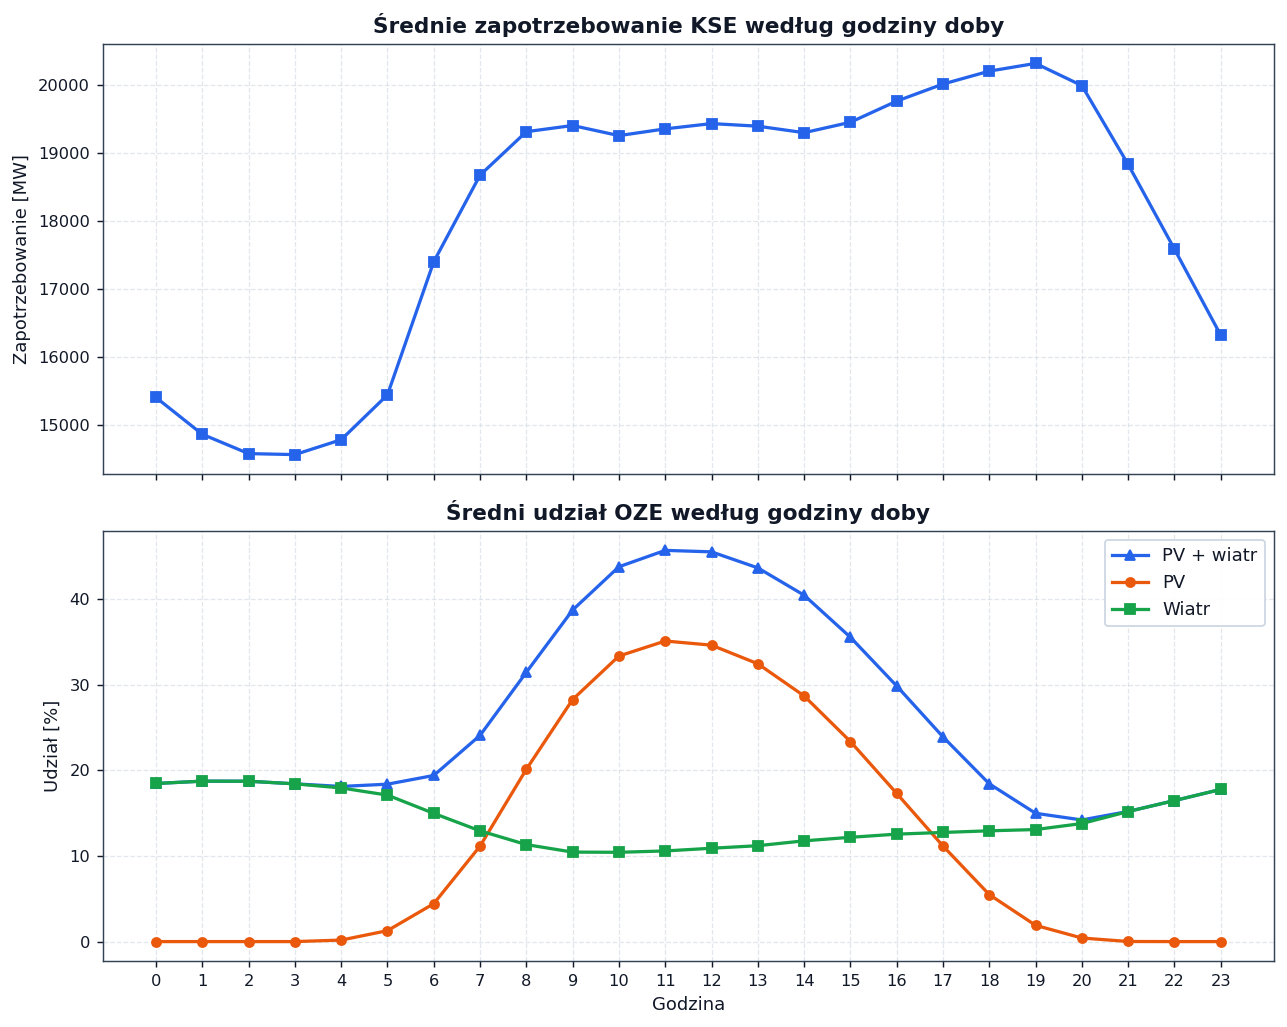

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
style_figure(fig)
for ax in axes:
    style_axes(ax)

axes[0].plot(
    hourly.index, hourly["load_kse"],
    marker="s",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["primary"]
)
axes[0].set_title("Średnie zapotrzebowanie KSE według godziny doby")
axes[0].set_ylabel("Zapotrzebowanie [MW]")

axes[1].plot(
    hourly.index, hourly["res_share"] * 100,
    marker="^",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["primary"],
    label="PV + wiatr"
)
axes[1].plot(
    hourly.index, hourly["pv_share"] * 100,
    marker="o",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["secondary"],
    label="PV"
)
axes[1].plot(
    hourly.index, hourly["wind_share"] * 100,
    marker="s",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["tertiary"],
    label="Wiatr"
)
axes[1].set_title("Średni udział OZE według godziny doby")
axes[1].set_xlabel("Godzina")
axes[1].set_ylabel("Udział [%]")
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
plt.show()


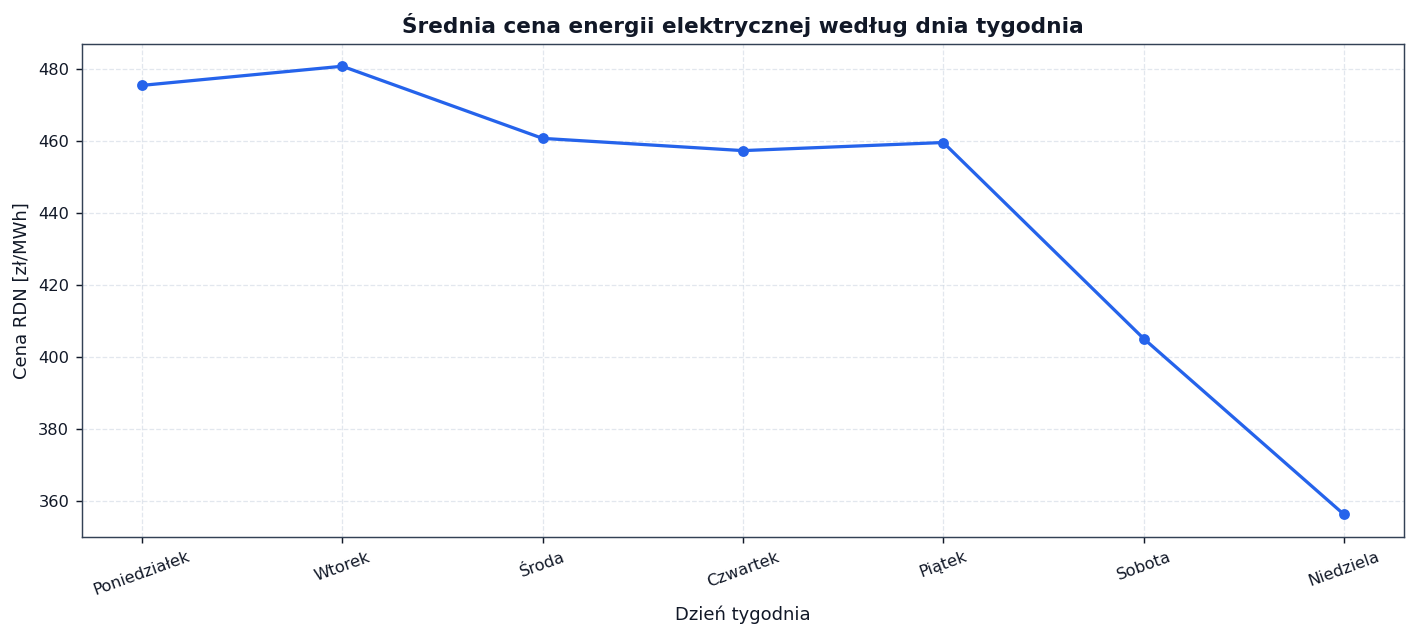

In [13]:
weekday_plot = weekday.copy()
weekday_plot.index = [weekday_labels[i] for i in weekday_plot.index]

fig, ax = plt.subplots(figsize=(11, 5))
style_figure(fig)
style_axes(ax)

ax.plot(
    range(len(weekday_plot)), weekday_plot["price_rdn"],
    marker="o",
    linewidth=1.8,
    markersize=5,
    color=ACADEMIC_COLORS["primary"]
)
ax.set_title("Średnia cena energii elektrycznej według dnia tygodnia")
ax.set_xlabel("Dzień tygodnia")
ax.set_ylabel("Cena RDN [zł/MWh]")
ax.set_xticks(range(len(weekday_plot.index)))
ax.set_xticklabels(weekday_plot.index, rotation=20)
plt.tight_layout()
plt.show()


In [14]:
analysis_cols = [
    "price_rdn", "load_kse", "temp_avg_pl",
    "wind_share", "pv_share", "res_share",
    "interchange_balance_mw", "load_diff_real_vs_planned"
]

pearson_corr = df[analysis_cols].corr(method="pearson")
spearman_corr = df[analysis_cols].corr(method="spearman")

price_corr = pd.DataFrame({
    "pearson": pearson_corr["price_rdn"],
    "spearman": spearman_corr["price_rdn"]
}).sort_values("pearson", ascending=False)

print("Korelacje z ceną RDN:")
print(price_corr)

Korelacje z ceną RDN:
                            pearson  spearman
price_rdn                  1.000000  1.000000
interchange_balance_mw     0.511128  0.503998
load_kse                   0.454010  0.507812
load_diff_real_vs_planned  0.198695  0.174611
temp_avg_pl               -0.196981 -0.251793
wind_share                -0.246174 -0.262286
pv_share                  -0.550412 -0.343729
res_share                 -0.685543 -0.673543


In [15]:
def plot_corr_matrix(corr_matrix: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    style_figure(fig)
    style_axes(ax, grid=False)

    im = ax.imshow(corr_matrix.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns, rotation=90)
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title(title)

    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            value = corr_matrix.iloc[i, j]
            text_color = ACADEMIC_COLORS["background"] if abs(value) >= 0.55 else ACADEMIC_COLORS["text"]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.outline.set_edgecolor(ACADEMIC_COLORS["axis"])
    cbar.ax.tick_params(colors=ACADEMIC_COLORS["text"], labelsize=8)
    plt.tight_layout()
    plt.show()


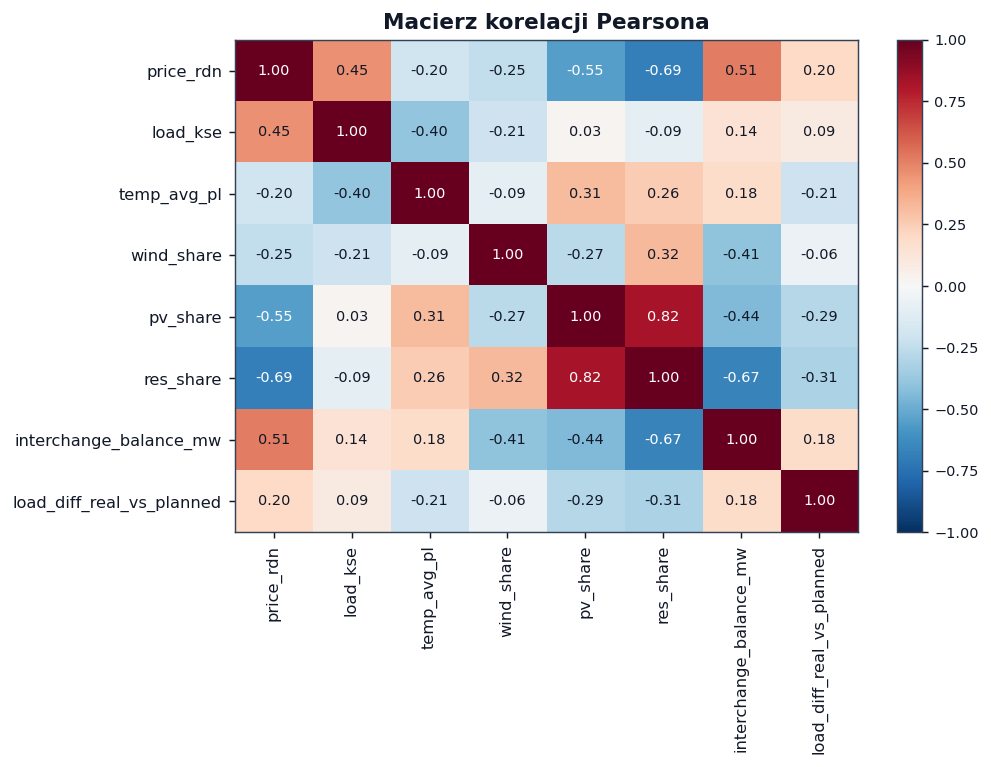

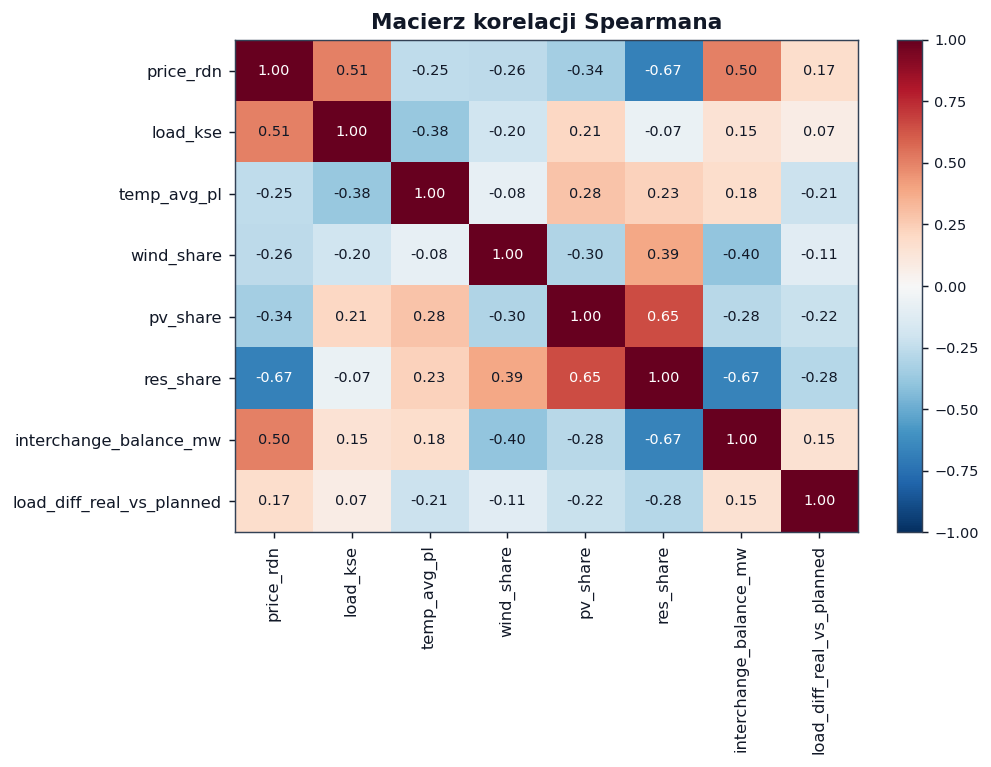

In [16]:
plot_corr_matrix(pearson_corr, "Macierz korelacji Pearsona")
plot_corr_matrix(spearman_corr, "Macierz korelacji Spearmana")

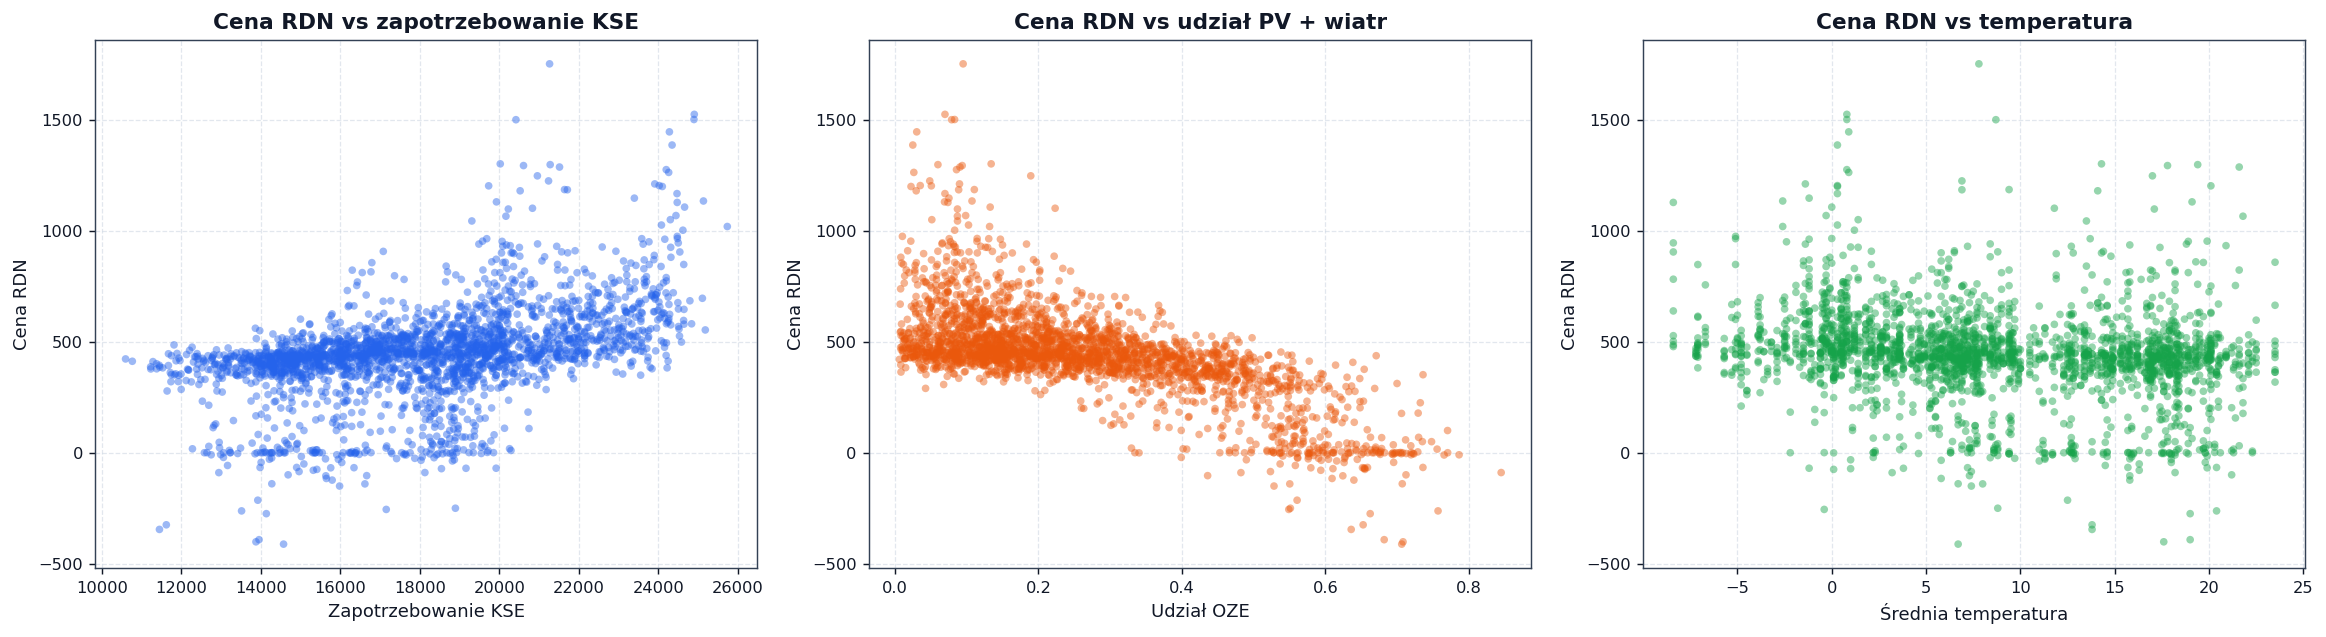

In [17]:
sample_df = df.sample(min(2500, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
style_figure(fig)
for ax in axes:
    style_axes(ax)

axes[0].scatter(
    sample_df["load_kse"], sample_df["price_rdn"],
    alpha=0.45,
    s=18,
    color=ACADEMIC_COLORS["primary"],
    edgecolors="none"
)
axes[0].set_title("Cena RDN vs zapotrzebowanie KSE")
axes[0].set_xlabel("Zapotrzebowanie KSE")
axes[0].set_ylabel("Cena RDN")

axes[1].scatter(
    sample_df["res_share"], sample_df["price_rdn"],
    alpha=0.45,
    s=18,
    color=ACADEMIC_COLORS["secondary"],
    edgecolors="none"
)
axes[1].set_title("Cena RDN vs udział PV + wiatr")
axes[1].set_xlabel("Udział OZE")
axes[1].set_ylabel("Cena RDN")

axes[2].scatter(
    sample_df["temp_avg_pl"], sample_df["price_rdn"],
    alpha=0.45,
    s=18,
    color=ACADEMIC_COLORS["tertiary"],
    edgecolors="none"
)
axes[2].set_title("Cena RDN vs temperatura")
axes[2].set_xlabel("Średnia temperatura")
axes[2].set_ylabel("Cena RDN")

plt.tight_layout()
plt.show()


In [18]:
print("\nRozszerzony test Dickeya-Fullera (ADF) dla ceny RDN")

adf_data = df["price_rdn"].dropna()

adf_result = adfuller(adf_data, autolag='AIC')

print(f"Statystyka testowa ADF: {adf_result[0]:.4f}")
print(f"Wartość p (p-value): {adf_result[1]:.4e}")
print("Wartości krytyczne:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nWniosek: Odrzucamy hipotezę zerową o istnieniu pierwiastka jednostkowego.")
    print("Szereg cen RDN JEST STACJONARNY. Można stosować modele regresji.")
else:
    print("\nWniosek: Brak podstaw do odrzucenia hipotezy zerowej.")
    print("Szereg cen RDN JEST NIESTACJONARNY (posiada pierwiastek jednostkowy).")


Rozszerzony test Dickeya-Fullera (ADF) dla ceny RDN
Statystyka testowa ADF: -10.7919
Wartość p (p-value): 2.1221e-19
Wartości krytyczne:
  1%: -3.4311
  5%: -2.8619
  10%: -2.5669

Wniosek: Odrzucamy hipotezę zerową o istnieniu pierwiastka jednostkowego.
Szereg cen RDN JEST STACJONARNY. Można stosować modele regresji.


In [19]:
def add_standardized_columns(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    #Dodaje standaryzowane wersje zmiennych.
    out = data.copy()
    for col in columns:
        out[f"z_{col}"] = (out[col] - out[col].mean()) / out[col].std()
    return out


reg_df = add_standardized_columns(
    df,
    [
        "price_rdn", "load_kse", "temp_avg_pl", "res_share",
        "wind_share", "pv_share", "interchange_balance_mw",
        "load_diff_real_vs_planned"
    ]
)

In [20]:
formula_res = """
z_price_rdn ~ z_load_kse + z_temp_avg_pl + z_res_share
            + z_interchange_balance_mw + z_load_diff_real_vs_planned
            + C(hour) + C(weekday) + C(month)
"""

model_res = smf.ols(formula=formula_res, data=reg_df).fit(
    cov_type="HAC", cov_kwds={"maxlags": 24}
)

print("Model regresji z łącznym udziałem OZE")
print(model_res.summary())

Model regresji z łącznym udziałem OZE
                            OLS Regression Results                            
Dep. Variable:            z_price_rdn   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     75.42
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:15:18   Log-Likelihood:                -7038.7
No. Observations:                8760   AIC:                         1.417e+04
Df Residuals:                    8714   BIC:                         1.449e+04
Df Model:                          45                                         
Covariance Type:                  HAC                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [21]:
coef_table_res = pd.DataFrame({
    "coef": model_res.params,
    "p_value": model_res.pvalues
})

print("Najważniejsze współczynniki - model z łącznym udziałem OZE")
print(coef_table_res.loc[
    ["z_load_kse", "z_temp_avg_pl", "z_res_share",
     "z_interchange_balance_mw", "z_load_diff_real_vs_planned"]
])

Najważniejsze współczynniki - model z łącznym udziałem OZE
                                 coef        p_value
z_load_kse                   0.634721   6.052744e-46
z_temp_avg_pl                0.063417   3.035544e-02
z_res_share                 -0.745402  2.429849e-113
z_interchange_balance_mw    -0.180994   3.239341e-12
z_load_diff_real_vs_planned -0.021647   1.211197e-01


In [22]:
formula_wp = """
z_price_rdn ~ z_load_kse + z_temp_avg_pl + z_wind_share + z_pv_share
            + z_interchange_balance_mw + z_load_diff_real_vs_planned
            + C(hour) + C(weekday) + C(month)
"""

model_wp = smf.ols(formula=formula_wp, data=reg_df).fit(
    cov_type="HAC", cov_kwds={"maxlags": 24}
)

print("Model regresji z rozbiciem OZE na wiatr i PV")
print(model_wp.summary())

Model regresji z rozbiciem OZE na wiatr i PV
                            OLS Regression Results                            
Dep. Variable:            z_price_rdn   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     80.61
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:15:22   Log-Likelihood:                -6982.3
No. Observations:                8760   AIC:                         1.406e+04
Df Residuals:                    8713   BIC:                         1.439e+04
Df Model:                          46                                         
Covariance Type:                  HAC                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

In [23]:
coef_table_wp = pd.DataFrame({
    "coef": model_wp.params,
    "p_value": model_wp.pvalues
})

print("Najważniejsze współczynniki - model z rozbiciem OZE")
print(coef_table_wp.loc[
    ["z_load_kse", "z_temp_avg_pl", "z_wind_share", "z_pv_share",
     "z_interchange_balance_mw", "z_load_diff_real_vs_planned"]
])

Najważniejsze współczynniki - model z rozbiciem OZE
                                 coef        p_value
z_load_kse                   0.603853   1.285178e-38
z_temp_avg_pl                0.070502   1.526714e-02
z_wind_share                -0.400625   1.737242e-86
z_pv_share                  -0.833675  8.239922e-118
z_interchange_balance_mw    -0.190357   5.966569e-14
z_load_diff_real_vs_planned -0.022508   1.133045e-01


In [24]:
def make_day_ahead_dataset(data: pd.DataFrame) -> pd.DataFrame:

    out = data.copy().sort_values(["timestamp", "hour_no"]).reset_index(drop=True)

    for lag in [24, 48, 72, 168]:
        out[f"price_lag_{lag}"] = out["price_rdn"].shift(lag)

    for lag in [24, 48, 72, 168]:
        out[f"load_lag_{lag}"] = out["load_kse"].shift(lag)
        out[f"temp_lag_{lag}"] = out["temp_avg_pl"].shift(lag)
        out[f"res_lag_{lag}"] = out["res_share"].shift(lag)
        out[f"balance_lag_{lag}"] = out["interchange_balance_mw"].shift(lag)

    out["price_mean_prev_24h"] = out["price_rdn"].shift(24).rolling(24).mean()
    out["price_mean_prev_7d"] = out["price_rdn"].shift(24).rolling(24 * 7).mean()
    out["price_std_prev_7d"] = out["price_rdn"].shift(24).rolling(24 * 7).std()

    out["load_mean_prev_7d"] = out["load_kse"].shift(24).rolling(24 * 7).mean()
    out["res_mean_prev_7d"] = out["res_share"].shift(24).rolling(24 * 7).mean()

    out["hour"] = out["timestamp"].dt.hour
    out["weekday"] = out["timestamp"].dt.dayofweek
    out["month"] = out["timestamp"].dt.month
    out["is_weekend"] = (out["weekday"] >= 5).astype(int)

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)

    out["weekday_sin"] = np.sin(2 * np.pi * out["weekday"] / 7)
    out["weekday_cos"] = np.cos(2 * np.pi * out["weekday"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * (out["month"] - 1) / 12)
    out["month_cos"] = np.cos(2 * np.pi * (out["month"] - 1) / 12)

    out = out.dropna().reset_index(drop=True)
    return out

In [25]:
model_df = make_day_ahead_dataset(df)

print("Liczba obserwacji po utworzeniu cech prognostycznych:", len(model_df))
model_df.head()

Liczba obserwacji po utworzeniu cech prognostycznych: 8569


,timestamp,hour_no,hour_interval,delivery_date,price_rdn,price_bal,interchange_balance_mw,load_kse,load_diff_real_vs_planned,wind_share,...,price_mean_prev_7d,price_std_prev_7d,load_mean_prev_7d,res_mean_prev_7d,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
0,2025-01-08 23:00:00,24,23:00-00:00,2025-01-08 23:00:00,443.45,379.8775,-1748.50275,18272.29250,734.79250,0.239899,...,319.858750,200.188139,17908.562256,0.352054,-0.258819,0.965926,0.974928,-0.222521,0.0,1.0
1,2025-01-09 00:00:00,1,00:00-01:00,2025-01-09 00:00:00,441.52,222.2125,-519.41225,17230.48475,455.48475,0.230473,...,321.281845,199.219861,17924.424019,0.351660,0.000000,1.000000,0.433884,-0.900969,0.0,1.0
2,2025-01-09 01:00:00,2,01:00-02:00,2025-01-09 01:00:00,437.55,382.5225,-1092.29525,16564.67925,314.67925,0.208926,...,322.889345,197.772276,17936.107438,0.351368,0.258819,0.965926,0.433884,-0.900969,0.0,1.0
3,2025-01-09 02:00:00,3,02:00-03:00,2025-01-09 02:00:00,430.52,398.2800,-1180.99650,16329.63400,317.13400,0.213706,...,324.249167,196.383792,17949.393682,0.351132,0.500000,0.866025,0.433884,-0.900969,0.0,1.0
4,2025-01-09 03:00:00,4,03:00-04:00,2025-01-09 03:00:00,419.25,87.0350,-479.54950,16260.84950,273.34950,0.201291,...,325.548333,194.991015,17965.172527,0.350764,0.707107,0.707107,0.433884,-0.900969,0.0,1.0


In [26]:
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print("Train:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test :", test_df["timestamp"].min(), "->", test_df["timestamp"].max())

target = "price_rdn"
#Model AR (historia ceny + dni kalendarzowe)
price_features = [
    "price_lag_24", "price_lag_48", "price_lag_72", "price_lag_168",
    "price_mean_prev_24h", "price_mean_prev_7d", "price_std_prev_7d",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "month_sin", "month_cos",
    "is_weekend"
]
#Model ARX (hisotria ceny + opóźnione determinanty)
arx_features = price_features + [
    "load_lag_24", "load_lag_48", "load_lag_72", "load_lag_168",
    "temp_lag_24", "temp_lag_48", "temp_lag_72", "temp_lag_168",
    "res_lag_24", "res_lag_48", "res_lag_72", "res_lag_168",
    "balance_lag_24", "balance_lag_48", "balance_lag_72", "balance_lag_168",
    "load_mean_prev_7d", "res_mean_prev_7d"
]

X_train_ar = train_df[price_features]
X_test_ar = test_df[price_features]

X_train_arx = train_df[arx_features]
X_test_arx = test_df[arx_features]

y_train = train_df[target]
y_test = test_df[target]

Train: 2025-01-08 23:00:00 -> 2025-10-21 14:00:00
Test : 2025-10-21 15:00:00 -> 2025-12-31 23:00:00


In [27]:
def smape(y_true, y_pred) -> float:
#Miara błędu względnego przy porównywaniu modeli
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
    ) * 100


def evaluate_forecast(y_true, y_pred, model_name: str) -> dict:
#Podstawowe miary jakości prognozy dla jednego modelu
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred)
    }


results = []
predictions = {}

In [28]:
pred_naive_d1 = test_df["price_lag_24"].values
predictions["Naive_D-1"] = pred_naive_d1
results.append(evaluate_forecast(y_test, pred_naive_d1, "Naive_D-1"))

pred_naive_w1 = test_df["price_lag_168"].values
predictions["Naive_W-1"] = pred_naive_w1
results.append(evaluate_forecast(y_test, pred_naive_w1, "Naive_W-1"))

In [29]:
model_ar = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

model_ar.fit(X_train_ar, y_train)
pred_ar = model_ar.predict(X_test_ar)
predictions["Linear_AR"] = pred_ar
results.append(evaluate_forecast(y_test, pred_ar, "Linear_AR"))

In [30]:
tscv = TimeSeriesSplit(n_splits=5)

model_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(
        alphas=np.logspace(-3, 3, 25),
        cv=tscv
    ))
])

model_ridge.fit(X_train_arx, y_train)
pred_ridge = model_ridge.predict(X_test_arx)
predictions["Ridge_ARX"] = pred_ridge
results.append(evaluate_forecast(y_test, pred_ridge, "Ridge_ARX"))

In [31]:
model_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        alphas=np.logspace(-4, 1, 80),
        cv=tscv,
        max_iter=30000,
        random_state=42
    ))
])

model_lasso.fit(X_train_arx, y_train)
pred_lasso = model_lasso.predict(X_test_arx)
predictions["Lasso_ARX"] = pred_lasso
results.append(evaluate_forecast(y_test, pred_lasso, "Lasso_ARX"))

In [32]:
model_hgb = HistGradientBoostingRegressor(
    random_state=42,
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=20,
    l2_regularization=0.1
)

model_hgb.fit(X_train_arx, y_train)
pred_hgb = model_hgb.predict(X_test_arx)
predictions["HGB_ARX"] = pred_hgb
results.append(evaluate_forecast(y_test, pred_hgb, "HGB_ARX"))

In [33]:
#Tworzymy wstępną tabelę
results_df = pd.DataFrame(results)

#Bazowe MAE oraz RMSE dla modelu naiwnego D-1
baseline_mae_d1 = results_df.loc[results_df["model"] == "Naive_D-1", "MAE"].iloc[0]
baseline_rmse_d1 = results_df.loc[results_df["model"] == "Naive_D-1", "RMSE"].iloc[0]

#Obliczamy rMAE - odporna miara
#Jeśli rMAE < 1, to model lepszy niż benchmark.
results_df["rMAE"] = results_df["MAE"] / baseline_mae_d1

#Poprawa wyrażona w %
results_df["MAE_vs_Naive_D1_%"] = (
    (baseline_mae_d1 - results_df["MAE"]) / baseline_mae_d1 * 100
)
results_df["RMSE_vs_Naive_D1_%"] = (
    (baseline_rmse_d1 - results_df["RMSE"]) / baseline_rmse_d1 * 100
)

#Sortujemy po rMAE rosnąco (im mniej, tym lepiej)
results_df = results_df.sort_values("rMAE").reset_index(drop=True)

columns_order = [
    "model", "MAE", "RMSE", "rMAE", "sMAPE",
    "MAE_vs_Naive_D1_%", "RMSE_vs_Naive_D1_%"
]
results_df = results_df[columns_order]

print("\nTabela wyników modeli prognostycznych (posortowana wg rMAE):")
print(results_df.round(4).to_string())


Tabela wyników modeli prognostycznych (posortowana wg rMAE):
       model       MAE      RMSE    rMAE    sMAPE  MAE_vs_Naive_D1_%  RMSE_vs_Naive_D1_%
0  Lasso_ARX  100.2712  149.7260  0.9428  20.6573             5.7237             16.6247
1  Linear_AR  102.6297  154.0270  0.9649  20.7272             3.5062             14.2297
2  Ridge_ARX  103.0273  152.1195  0.9687  21.3262             3.1324             15.2919
3  Naive_D-1  106.3588  179.5808  1.0000  21.3255             0.0000              0.0000
4    HGB_ARX  111.7919  174.5866  1.0511  23.5949            -5.1083              2.7810
5  Naive_W-1  124.1272  204.0743  1.1671  24.7599           -16.7060            -13.6393


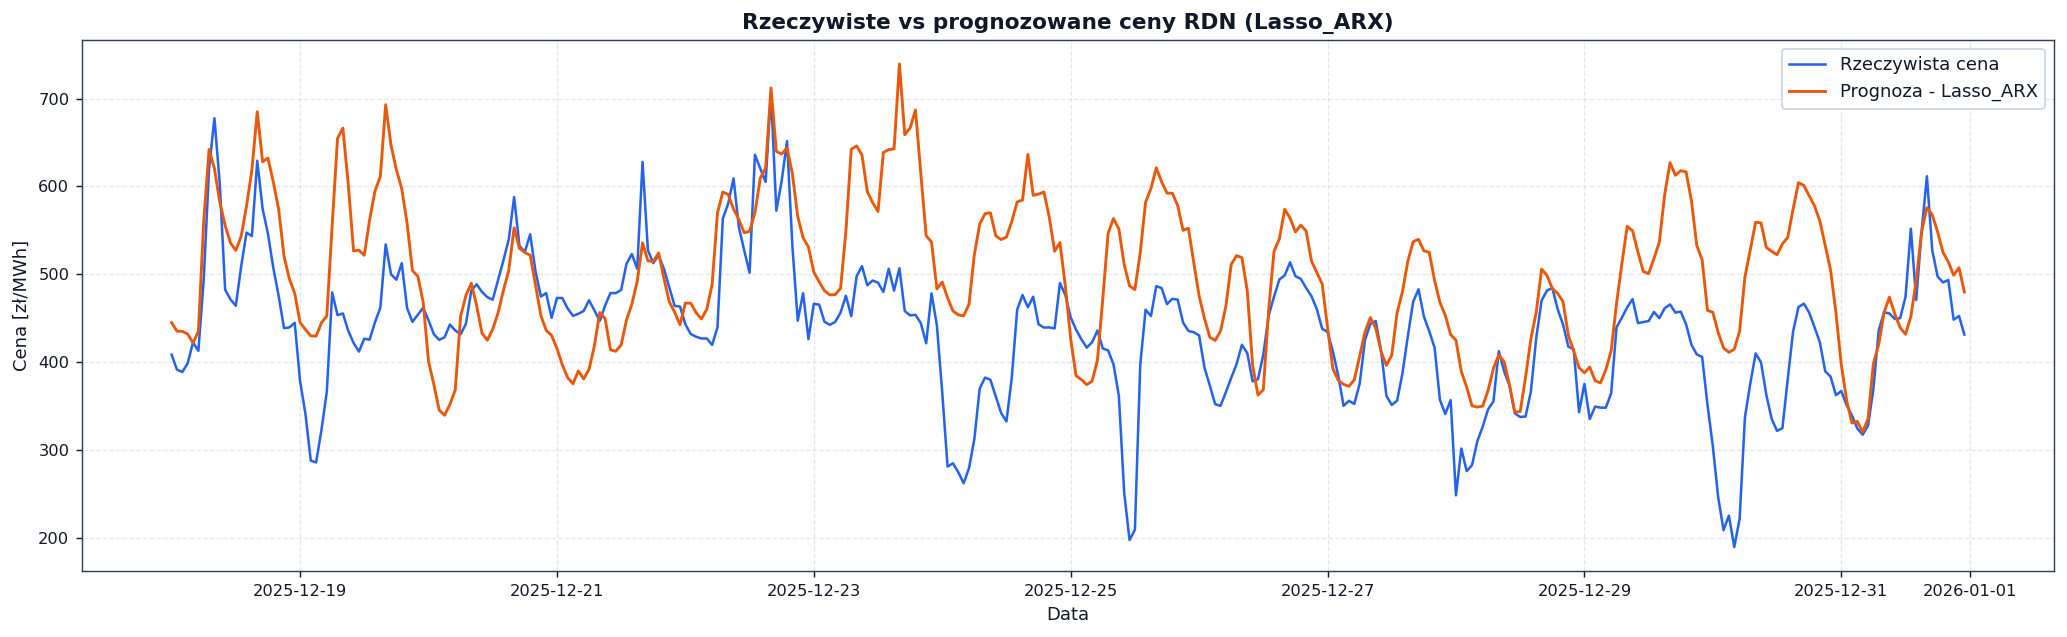

In [34]:
best_model_name = results_df.iloc[0]["model"]
best_pred = predictions[best_model_name]

plot_df = test_df[["timestamp", "price_rdn"]].copy()
plot_df["prediction"] = best_pred

plot_last = plot_df.tail(24 * 14)

fig, ax = plt.subplots(figsize=(16, 5))
style_figure(fig)
style_axes(ax)

ax.plot(
    plot_last["timestamp"], plot_last["price_rdn"],
    linewidth=1.4,
    color=ACADEMIC_COLORS["primary"],
    label="Rzeczywista cena"
)
ax.plot(
    plot_last["timestamp"], plot_last["prediction"],
    linewidth=1.6,
    color=ACADEMIC_COLORS["secondary"],
    label=f"Prognoza - {best_model_name}"
)
ax.set_title(f"Rzeczywiste vs prognozowane ceny RDN ({best_model_name})")
ax.set_xlabel("Data")
ax.set_ylabel("Cena [zł/MWh]")
ax.legend()
plt.tight_layout()
plt.show()


In [35]:
lasso_model = model_lasso.named_steps["model"]
lasso_coefs = pd.Series(
    lasso_model.coef_,
    index=arx_features,
    name="coef"
).sort_values(key=np.abs, ascending=False)

print("Najważniejsze współczynniki modelu Lasso (malejąco wg |coef|):")
print(lasso_coefs.head(20))

Najważniejsze współczynniki modelu Lasso (malejąco wg |coef|):
price_lag_24           90.264491
load_lag_168           49.085302
res_mean_prev_7d       44.484656
res_lag_24            -35.820252
price_lag_168          27.938704
price_mean_prev_24h   -24.437598
balance_lag_24        -23.893714
price_lag_72           21.383645
res_lag_48            -20.201531
price_std_prev_7d     -19.421267
month_sin             -18.873288
hour_cos               15.541136
is_weekend            -14.611939
price_lag_48           12.445634
weekday_cos            11.869389
temp_lag_24            -9.636030
load_lag_72             3.069732
hour_sin                2.971160
temp_lag_72             1.408955
balance_lag_72          1.329141
Name: coef, dtype: float64
